In [2]:
import numpy as np
import pandas as pd
import warnings
warnings.simplefilter("ignore", pd.errors.DtypeWarning)
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import dcor
import math
from glob import glob
import os
import ruptures as rpt
from scipy.stats import pearsonr
from ydata_profiling import ProfileReport
from helper_functions import (
    load_signal_data,
    clean_signals,
    correlate_with_vibration,
    extract_operating_periods,
    get_signal_df
)

In [3]:
folder = "step_interpolation_10s/G2_relevant"

dfs = load_signal_data(
    search_folder=folder
)

In [ ]:
vib_name = "DE Vibration"
vib = get_signal_df(dfs, vib_name)

vib.sort_values(by="signal", ascending=False)

In [4]:
dfs, cleaning_table = clean_signals(dfs)

cleaning_table

,Signal,Invalid values,Invalid [%]
0,Turbine inlet pressure,759,0.0578
1,DE Bearing temp,4,0.0003
2,DE Bearing oil temp,10,0.0008
3,DE Vibration,3,0.0002


In [ ]:
# Put all signal columns into one dataframe
profile_df = pd.DataFrame()

for i in range(len(dfs)):
    name = dfs.loc[i, "name"]
    signal_df = dfs.loc[i, "signal_df"]

    profile_df[name] = signal_df["signal"].reset_index(drop=True)

# Create report
profile = ProfileReport(
    profile_df,
    title="Signal data report",
    explorative=True
)

profile.to_file("signal_data_report.html")

In [7]:
summary_rows = []

for i in range(len(dfs)):
    name = dfs.loc[i, "name"]
    unit = dfs.loc[i, "unit"]
    df = dfs.loc[i, "signal_df"]

    x = df["signal"]
    unit_clean = str(unit).split(":")[-1] if pd.notna(unit) else ""

    summary_rows.append({
        "Signal": name,
        "Unit": unit_clean,
        "Mean": x.mean(),
        "Std. dev.": x.std(),
        "Min": x.min(),
        "Max": x.max(),
        "Zero [%]": 100 * (x == 0).mean(),
        "Negative [%]": 100 * (x < 0).mean(),
        "99th percentile": x.quantile(0.99)
    })

summary_table = pd.DataFrame(summary_rows)

summary_table = summary_table.round({
    "Mean": 3,
    "Std. dev.": 3,
    "Min": 3,
    "Max": 3,
    "Zero [%]": 2,
    "Negative [%]": 2,
    "99th percentile": 3
})

summary_table

,Signal,Unit,Mean,Std. dev.,Min,Max,Zero [%],Negative [%],99th percentile
0,Trykk i turbininnløp Middelverdi (Hydrocord),kilopa,3843.594,39.241,3737.572,3911.675,0.00,0.0,3893.645
1,DE Bearing temp,degrees,43.430,3.047,30.281,58.229,0.00,0.0,54.394
2,DE Bearing oil temp,degrees,43.957,3.028,29.175,60.227,0.00,0.0,50.020
3,DE Vibration,mm/s,0.494,0.107,0.000,1.743,0.04,0.0,0.648
4,Exciter curent,a,6.015,1.150,0.000,18.103,0.57,0.0,7.773
5,Set point,megaw,6.133,3.076,0.000,10.320,0.00,0.0,10.320
6,Generator active power,MW,6.057,3.091,0.000,10.600,0.63,0.0,10.260
7,Total needle opening position,percent,66.098,15.239,0.000,93.817,0.00,0.0,90.598
8,Rotational speed,percent,99.489,7.009,0.000,118.273,0.42,0.0,100.215
9,Turbine inlet pressure,bar,37.346,0.468,0.000,38.063,0.01,0.0,37.844


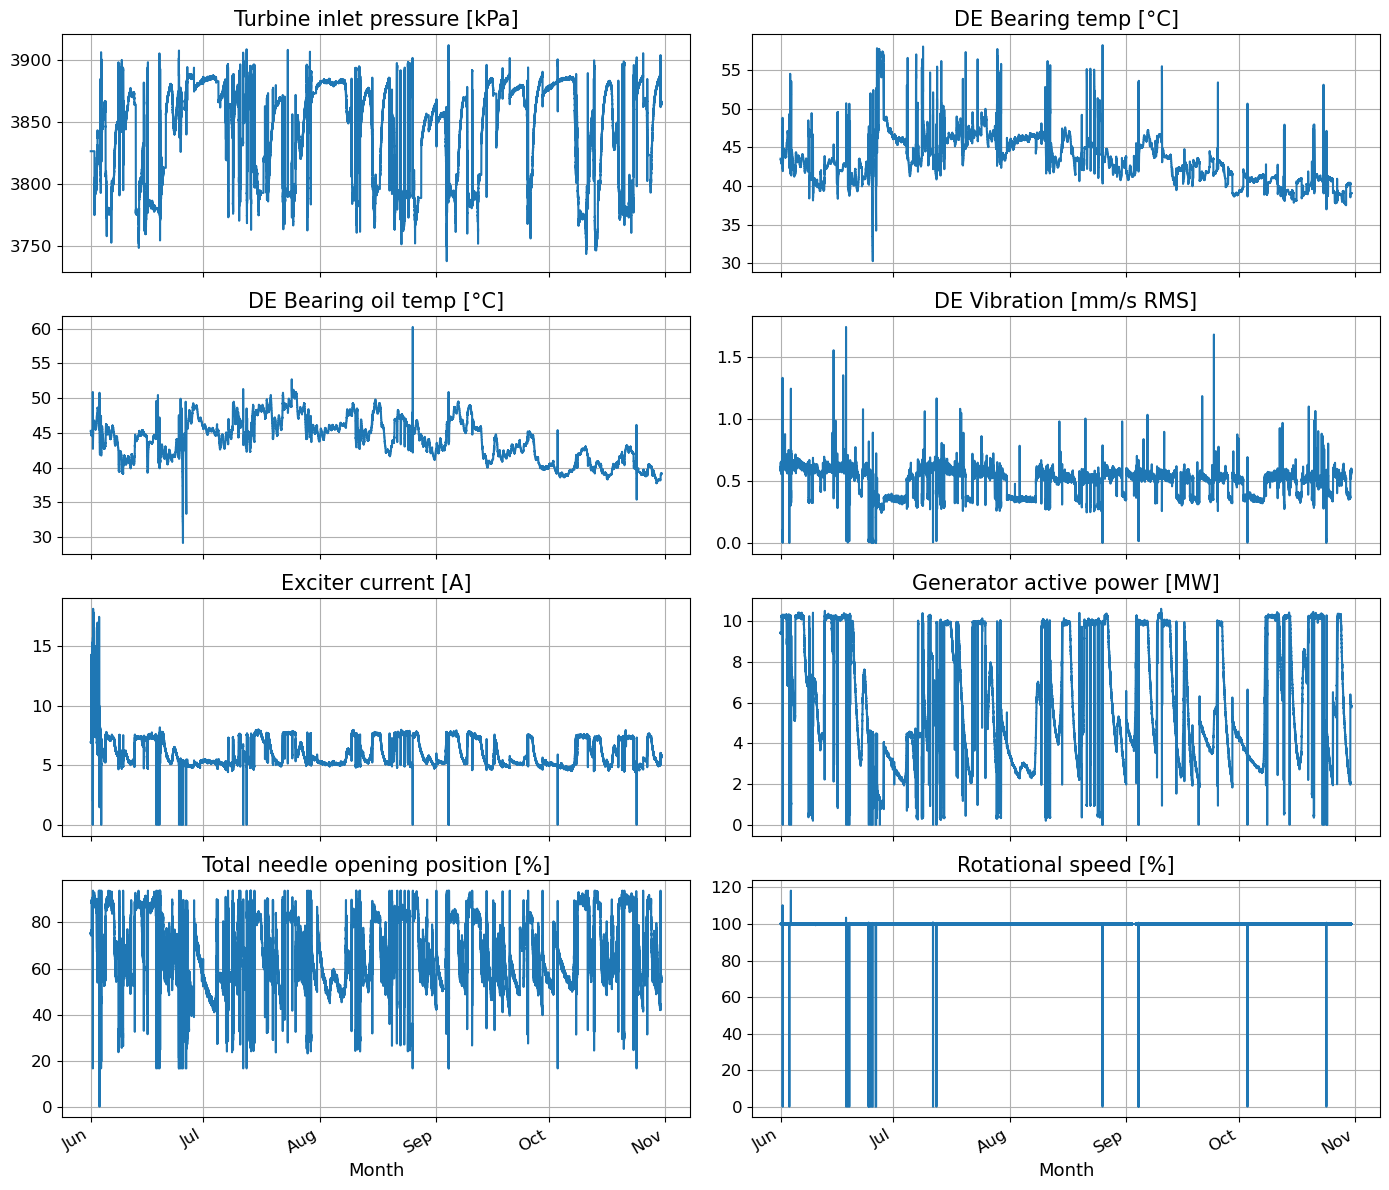

In [5]:
plot_dfs = dfs.loc[
    ~dfs["name"].str.lower().str.contains("vann|trykk oppstrøm|set point", na=False)
].reset_index(drop=True)

num_plots = len(plot_dfs)
num_cols = 2
num_rows = math.ceil(num_plots / num_cols)

fig, axes = plt.subplots(
    num_rows,
    num_cols,
    figsize=(14, 3.0 * num_rows)
)

axes = axes.flatten()

for i in range(num_plots):
    name = plot_dfs.loc[i, "name"]
    df = plot_dfs.loc[i, "signal_df"]
    unit = plot_dfs.loc[i, "unit"]

    title = f"{name} [{unit}]" if pd.notna(unit) else name

    axes[i].plot(df["Datetime"], df["signal"])
    axes[i].set_title(title, fontsize=15)
    axes[i].set_xlabel("Month", fontsize=13)
    axes[i].set_ylabel("")
    axes[i].tick_params(axis="both", labelsize=12)
    axes[i].grid(True)
    axes[i].xaxis.set_major_formatter(mdates.DateFormatter("%b"))

for ax in axes[num_plots:]:
    ax.remove()

fig.autofmt_xdate()
plt.tight_layout()

plt.savefig("selected_signal_values.png", dpi=300, bbox_inches="tight")

plt.show()

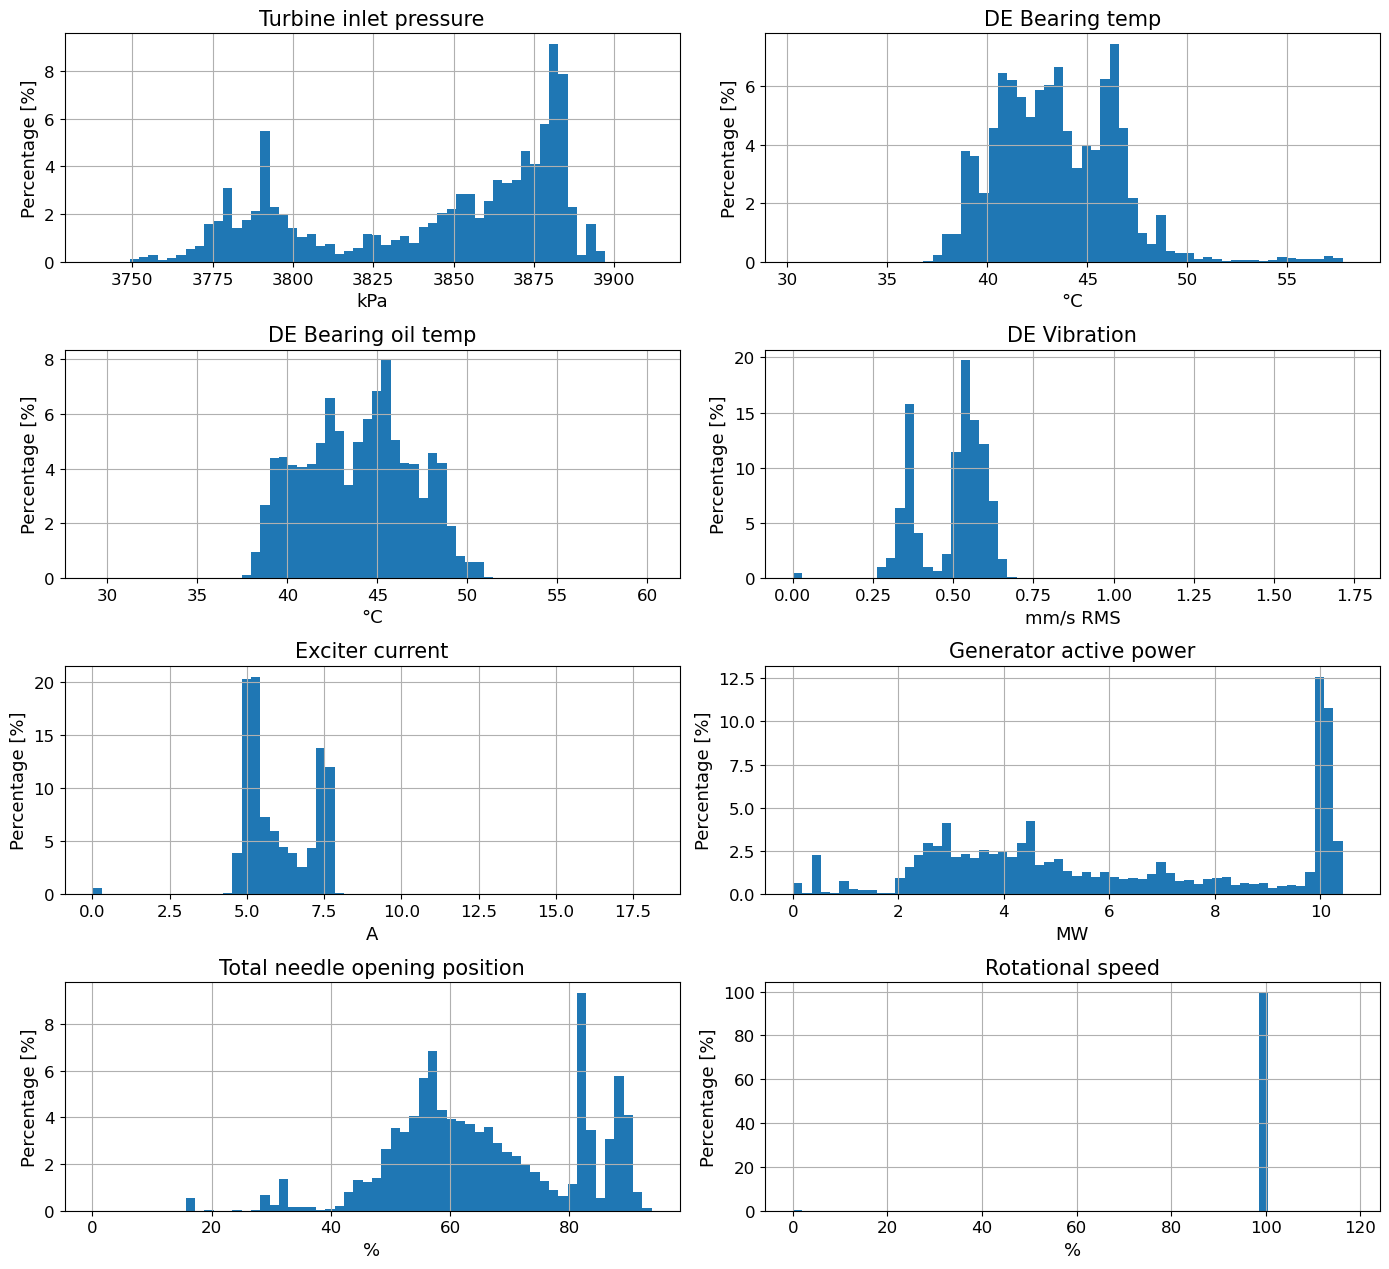

In [6]:
plot_dfs = dfs.loc[
    ~dfs["name"].str.lower().str.contains(
        "set point|vann|trykk oppstrøm",
        na=False
    )
].reset_index(drop=True)

num_plots = len(plot_dfs)
num_cols = 2
num_rows = math.ceil(num_plots / num_cols)

fig, axes = plt.subplots(
    num_rows,
    num_cols,
    figsize=(14, 3.2 * num_rows)
)

axes = axes.flatten()

for i in range(num_plots):
    name = plot_dfs.loc[i, "name"]
    df = plot_dfs.loc[i, "signal_df"]
    unit = plot_dfs.loc[i, "unit"]

    values = df["signal"].dropna()
    weights = np.ones(len(values)) * 100 / len(values)

    axes[i].hist(values, bins=60, weights=weights)

    axes[i].set_title(name, fontsize=15)
    axes[i].set_xlabel(
        unit if pd.notna(unit) else "Signal value",
        fontsize=13
    )
    axes[i].set_ylabel("Percentage [%]", fontsize=13)

    axes[i].tick_params(axis="both", labelsize=12)
    axes[i].grid(True)

for ax in axes[num_plots:]:
    ax.remove()

plt.tight_layout()
plt.savefig("selected_signal_histograms_percentage.png", dpi=300, bbox_inches="tight")
plt.show()

In [6]:
speed = dfs.loc[
    dfs["name"] == "Rotational speed",
    "signal_df"
].iloc[0]

power = dfs.loc[
    dfs["name"] == "Generator active power",
    "signal_df"
].iloc[0]

operating_periods = extract_operating_periods(
    speed_df=speed,
    power_df=power,
    speed_threshold=90,
    power_threshold=0.5,
    min_samples=30
)

operating_periods.head()

,start_time,end_time,n_samples
0,2024-06-01 00:00:00,2024-06-01 12:36:50,4542
1,2024-06-01 13:55:20,2024-06-03 07:38:30,15020
2,2024-06-03 08:01:10,2024-06-03 12:49:10,1729
3,2024-06-03 13:12:20,2024-06-03 17:54:30,1694
4,2024-06-03 19:08:40,2024-06-08 08:57:00,39531


In [7]:
corr_df = correlate_with_vibration(dfs, operating_periods, "DE Vibration")
corr_df

,Signal,Pearson,Distance
5,Generator active power,0.726454,0.719434
4,Set point,0.723595,0.717474
8,VANN Trykk oppstrøm,-0.603612,0.631563
3,Exciter current,0.630788,0.628380
0,Turbine inlet pressure,-0.608323,0.623502
6,Total needle opening position,0.485191,0.435836
2,DE Bearing oil temp,0.231498,0.236057
1,DE Bearing temp,-0.209588,0.219484
7,Rotational speed,0.024095,0.031077


In [10]:
symbol_map = {
    "Turbine inlet pressure": r"$p_{\mathrm{in}}$",
    "DE Bearing temp": r"$T_{\mathrm{bearing}}$",
    "DE Bearing oil temp": r"$T_{\mathrm{oil}}$",
    "DE Vibration": r"$V_{\mathrm{DE}}$",
    "Exciter current": r"$I_f$",
    "Generator active power": r"$P_G$",
    "Total needle opening position": r"$O$",
    "Rotational speed": r"$n$",
}

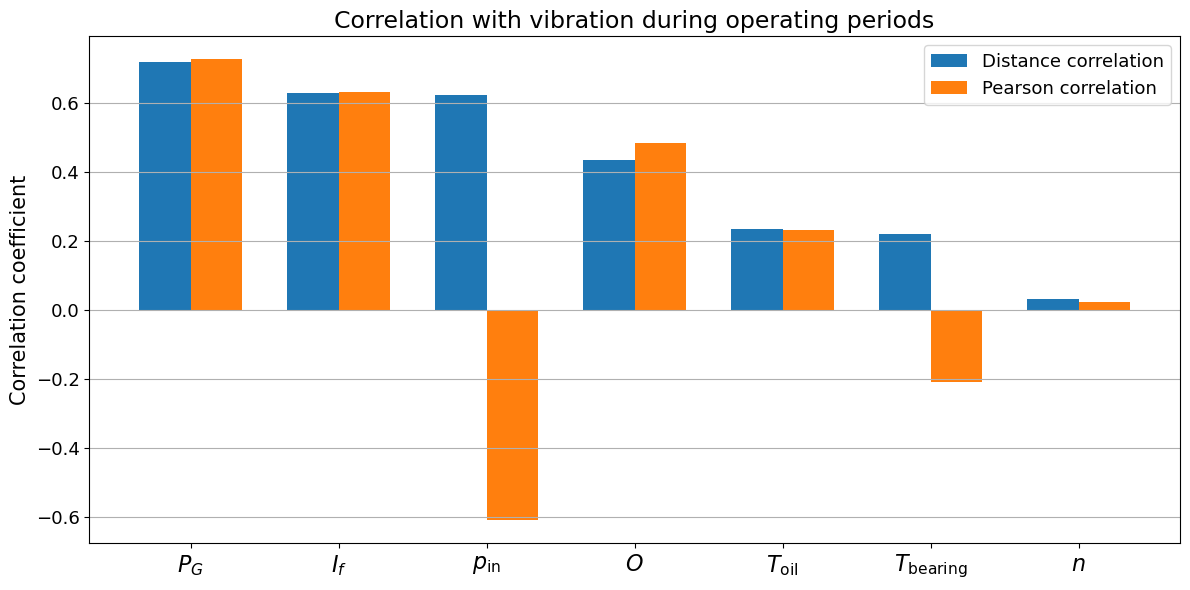

In [11]:
corr_plot_df = corr_df.loc[
    ~corr_df["Signal"].str.lower().str.contains(
        "vann|trykk oppstrøm|set point",
        na=False
    )
].copy()

corr_plot_df["Symbol"] = corr_plot_df["Signal"].map(symbol_map)

corr_plot_df = corr_plot_df.dropna(subset=["Symbol"]).reset_index(drop=True)

x = np.arange(len(corr_plot_df))
w = 0.35

plt.figure(figsize=(12, 6))

plt.bar(x - w / 2, corr_plot_df["Distance"], width=w, label="Distance correlation")
plt.bar(x + w / 2, corr_plot_df["Pearson"], width=w, label="Pearson correlation")

plt.xticks(x, corr_plot_df["Symbol"], fontsize=16)
plt.yticks(fontsize=13)

plt.ylabel("Correlation coefficient", fontsize=15)
plt.title("Correlation with vibration during operating periods", fontsize=17)

plt.grid(axis="y")
plt.legend(fontsize=13)
plt.tight_layout()

plt.savefig(
    "correlation_with_vibration_operating_periods.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()